# comparaison_es_vs_ml

In [11]:
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Setup
# ─────────────────────────────────────────────────────────────

import sys
from pathlib import Path
import warnings
import time
warnings.filterwarnings("ignore")

RACINE = Path("..").resolve()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from elasticsearch import Elasticsearch
import psycopg2
from sklearn.metrics import precision_score, recall_score, f1_score
from dotenv import load_dotenv
import os

load_dotenv(RACINE / ".env")
print("Imports OK")

Imports OK


In [12]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Connexions
# ─────────────────────────────────────────────────────────────

es = Elasticsearch(
    f"http://{os.getenv('ELASTIC_HOST', 'localhost')}:"
    f"{os.getenv('ELASTIC_PORT', 9200)}"
)
assert es.ping(), "Elasticsearch inaccessible"
print(f"ES connecté — {es.count(index='offres')['count']} documents")

conn = psycopg2.connect(
    host     = os.getenv("POSTGRES_HOST", "localhost"),
    port     = int(os.getenv("POSTGRES_PORT", 5432)),
    dbname   = os.getenv("POSTGRES_DB", "job_market"),
    user     = os.getenv("POSTGRES_USER"),
    password = os.getenv("POSTGRES_PASSWORD"),
)
print("PostgreSQL connecté")

ES connecté — 9079 documents
PostgreSQL connecté


In [13]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Charger le ground truth depuis PostgreSQL
# ─────────────────────────────────────────────────────────────

df_gt = pd.read_sql("""
    SELECT
        o.id,
        ml.ml_keyword,
        ml.ml_label_categorie
    FROM offres o
    JOIN ml_labels ml ON ml.offre_id = o.id
""", conn)

print(f"Ground truth : {len(df_gt)} offres labellisées")
print(f"\nKeywords disponibles :")
print(df_gt["ml_keyword"].value_counts().to_string())

Ground truth : 15048 offres labellisées

Keywords disponibles :
ml_keyword
data engineer                 600
business analyst              600
data manager                  600
ingénieur cloud               600
développeur fullstack         600
administrateur système        600
chef de projet                600
comptable                     600
responsable marketing         600
commercial                    600
chargé de communication       600
directeur financier           600
infirmier                     600
ingénieur data                571
pipeline données              571
data analyst                  483
ingénieur machine learning    410
ingénieur données             367
data scientist                329
scrum master                  269
devops engineer               260
UX designer                   257
business intelligence         252
architecte solution           248
product manager               248
architecte data               235
architecte données            225
dévelop

In [14]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Fonction d'évaluation ES par keyword
# ─────────────────────────────────────────────────────────────

def evaluer_keyword_es(
    keyword:      str,
    df_gt:        pd.DataFrame,
    nb_resultats: int = 100,
) -> dict:
    """
    Évalue Elasticsearch pour un keyword donné.

    Logique :
        - Lance la requête `keyword` dans ES
        - Pour chaque offre retournée, vérifie si son ml_keyword
          correspond au keyword recherché (via le ground truth PostgreSQL)
        - Calcule précision, rappel, F1

    Paramètres :
        keyword      : le mot-clé à rechercher (ex: "data engineer")
        df_gt        : ground truth depuis PostgreSQL
        nb_resultats : nombre de résultats ES à considérer

    Retourne :
        dict avec précision, rappel, F1, temps, détails
    """
    # ── Recherche dans Elasticsearch ──────────────────────────
    body = {
        "query": {
            "multi_match": {
                "query":  keyword,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": nb_resultats,
    }

    debut = time.perf_counter()
    res   = es.search(index="offres", body=body)
    temps_ms = (time.perf_counter() - debut) * 1000

    ids_retournes = [h["_id"] for h in res["hits"]["hits"]]

    # ── Ground truth pour ce keyword ──────────────────────────
    # Toutes les offres étiquetées avec ce keyword dans PostgreSQL
    ids_positifs_gt = set(
        df_gt[df_gt["ml_keyword"] == keyword]["id"].values
    )

    if not ids_positifs_gt:
        return {
            "keyword":        keyword,
            "precision":      None,
            "rappel":         None,
            "f1":             None,
            "temps_ms":       temps_ms,
            "avertissement":  f"Aucun label pour '{keyword}' dans PostgreSQL"
        }

    # ── Construction de y_true et y_pred ──────────────────────
    #
    # Pour chaque offre retournée par ES :
    #   y_pred = 1 (ES l'a retournée → elle est considérée pertinente)
    #   y_true = 1 si ml_keyword == keyword, 0 sinon
    #
    # Pour chaque offre positive (ml_keyword == keyword) non retournée :
    #   y_pred = 0 (ES ne l'a pas retournée)
    #   y_true = 1 (elle aurait dû être retournée)

    # Offres retournées ET présentes dans le ground truth
    ids_retournes_connus = [
        id_ for id_ in ids_retournes
        if id_ in set(df_gt["id"].values)
    ]

    # y pour les offres retournées
    y_true_retournes = [
        1 if id_ in ids_positifs_gt else 0
        for id_ in ids_retournes_connus
    ]
    y_pred_retournes = [1] * len(ids_retournes_connus)

    # Faux négatifs — offres positives non retournées par ES
    ids_retournes_set = set(ids_retournes)
    faux_negatifs     = [
        id_ for id_ in ids_positifs_gt
        if id_ not in ids_retournes_set
    ]

    # y pour les faux négatifs
    y_true_fn = [1] * len(faux_negatifs)
    y_pred_fn = [0] * len(faux_negatifs)

    # Assemblage final
    y_true = y_true_retournes + y_true_fn
    y_pred = y_pred_retournes + y_pred_fn

    if not y_true:
        return {
            "keyword":   keyword,
            "precision": 0.0,
            "rappel":    0.0,
            "f1":        0.0,
            "temps_ms":  temps_ms,
        }

    # ── Calcul des métriques ───────────────────────────────────
    precision = precision_score(y_true, y_pred, zero_division=0)
    rappel    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    return {
        "keyword":          keyword,
        "precision":        round(precision, 4),
        "rappel":           round(rappel, 4),
        "f1":               round(f1, 4),
        "temps_ms":         round(temps_ms, 2),
        "nb_positifs_gt":   len(ids_positifs_gt),
        "nb_retournes":     len(ids_retournes),
        "vrais_positifs":   int(sum(y_true_retournes)),
        "faux_positifs":    int(len(y_true_retournes) - sum(y_true_retournes)),
        "faux_negatifs":    len(faux_negatifs),
    }

print("Fonction définie")

Fonction définie


In [15]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Évaluation sur tous les keywords
# ─────────────────────────────────────────────────────────────

keywords_uniques = df_gt["ml_keyword"].unique().tolist()
print(f"Évaluation sur {len(keywords_uniques)} keywords...\n")

resultats = []

for keyword in keywords_uniques:
    m = evaluer_keyword_es(keyword, df_gt, nb_resultats=100)
    resultats.append(m)

    if m["precision"] is not None:
        print(
            f"  '{keyword}' — "
            f"P={m['precision']:.3f} "
            f"R={m['rappel']:.3f} "
            f"F1={m['f1']:.3f} "
            f"({m['temps_ms']:.1f}ms) "
            f"[VP={m['vrais_positifs']} "
            f"FP={m['faux_positifs']} "
            f"FN={m['faux_negatifs']}]"
        )
    else:
        print(f"  '{keyword}' — ⚠ {m['avertissement']}")

df_resultats = pd.DataFrame(resultats).dropna(subset=["precision"])
print(f"\n=== Résultats globaux ===")
print(f"Précision moyenne : {df_resultats['precision'].mean():.4f}")
print(f"Rappel moyen      : {df_resultats['rappel'].mean():.4f}")
print(f"F1 moyen          : {df_resultats['f1'].mean():.4f}")
print(f"Temps moyen       : {df_resultats['temps_ms'].mean():.2f} ms")

Évaluation sur 47 keywords...

  'data engineer' — P=0.960 R=0.160 F1=0.274 (31.2ms) [VP=96 FP=4 FN=504]
  'ingénieur données' — P=0.490 R=0.134 F1=0.210 (16.5ms) [VP=49 FP=51 FN=318]
  'ingénieur data' — P=0.980 R=0.172 F1=0.292 (20.3ms) [VP=98 FP=2 FN=473]
  'pipeline données' — P=0.360 R=0.063 F1=0.107 (11.0ms) [VP=36 FP=64 FN=535]
  'ETL développeur' — P=0.040 R=0.032 F1=0.035 (12.1ms) [VP=4 FP=96 FN=123]
  'architecte données' — P=0.790 R=0.351 F1=0.486 (14.8ms) [VP=79 FP=21 FN=146]
  'architecte data' — P=0.700 R=0.298 F1=0.418 (13.4ms) [VP=70 FP=30 FN=165]
  'MLOps' — P=0.200 R=0.171 F1=0.184 (10.6ms) [VP=20 FP=80 FN=97]
  'data scientist' — P=1.000 R=0.304 F1=0.466 (16.9ms) [VP=100 FP=0 FN=229]
  'machine learning engineer' — P=0.100 R=0.055 F1=0.071 (11.7ms) [VP=10 FP=90 FN=173]
  'ingénieur machine learning' — P=0.950 R=0.232 F1=0.372 (10.0ms) [VP=95 FP=5 FN=315]
  'NLP engineer' — P=0.030 R=0.030 F1=0.030 (14.6ms) [VP=3 FP=97 FN=98]
  'computer vision' — P=0.020 R=0.020 F1=0

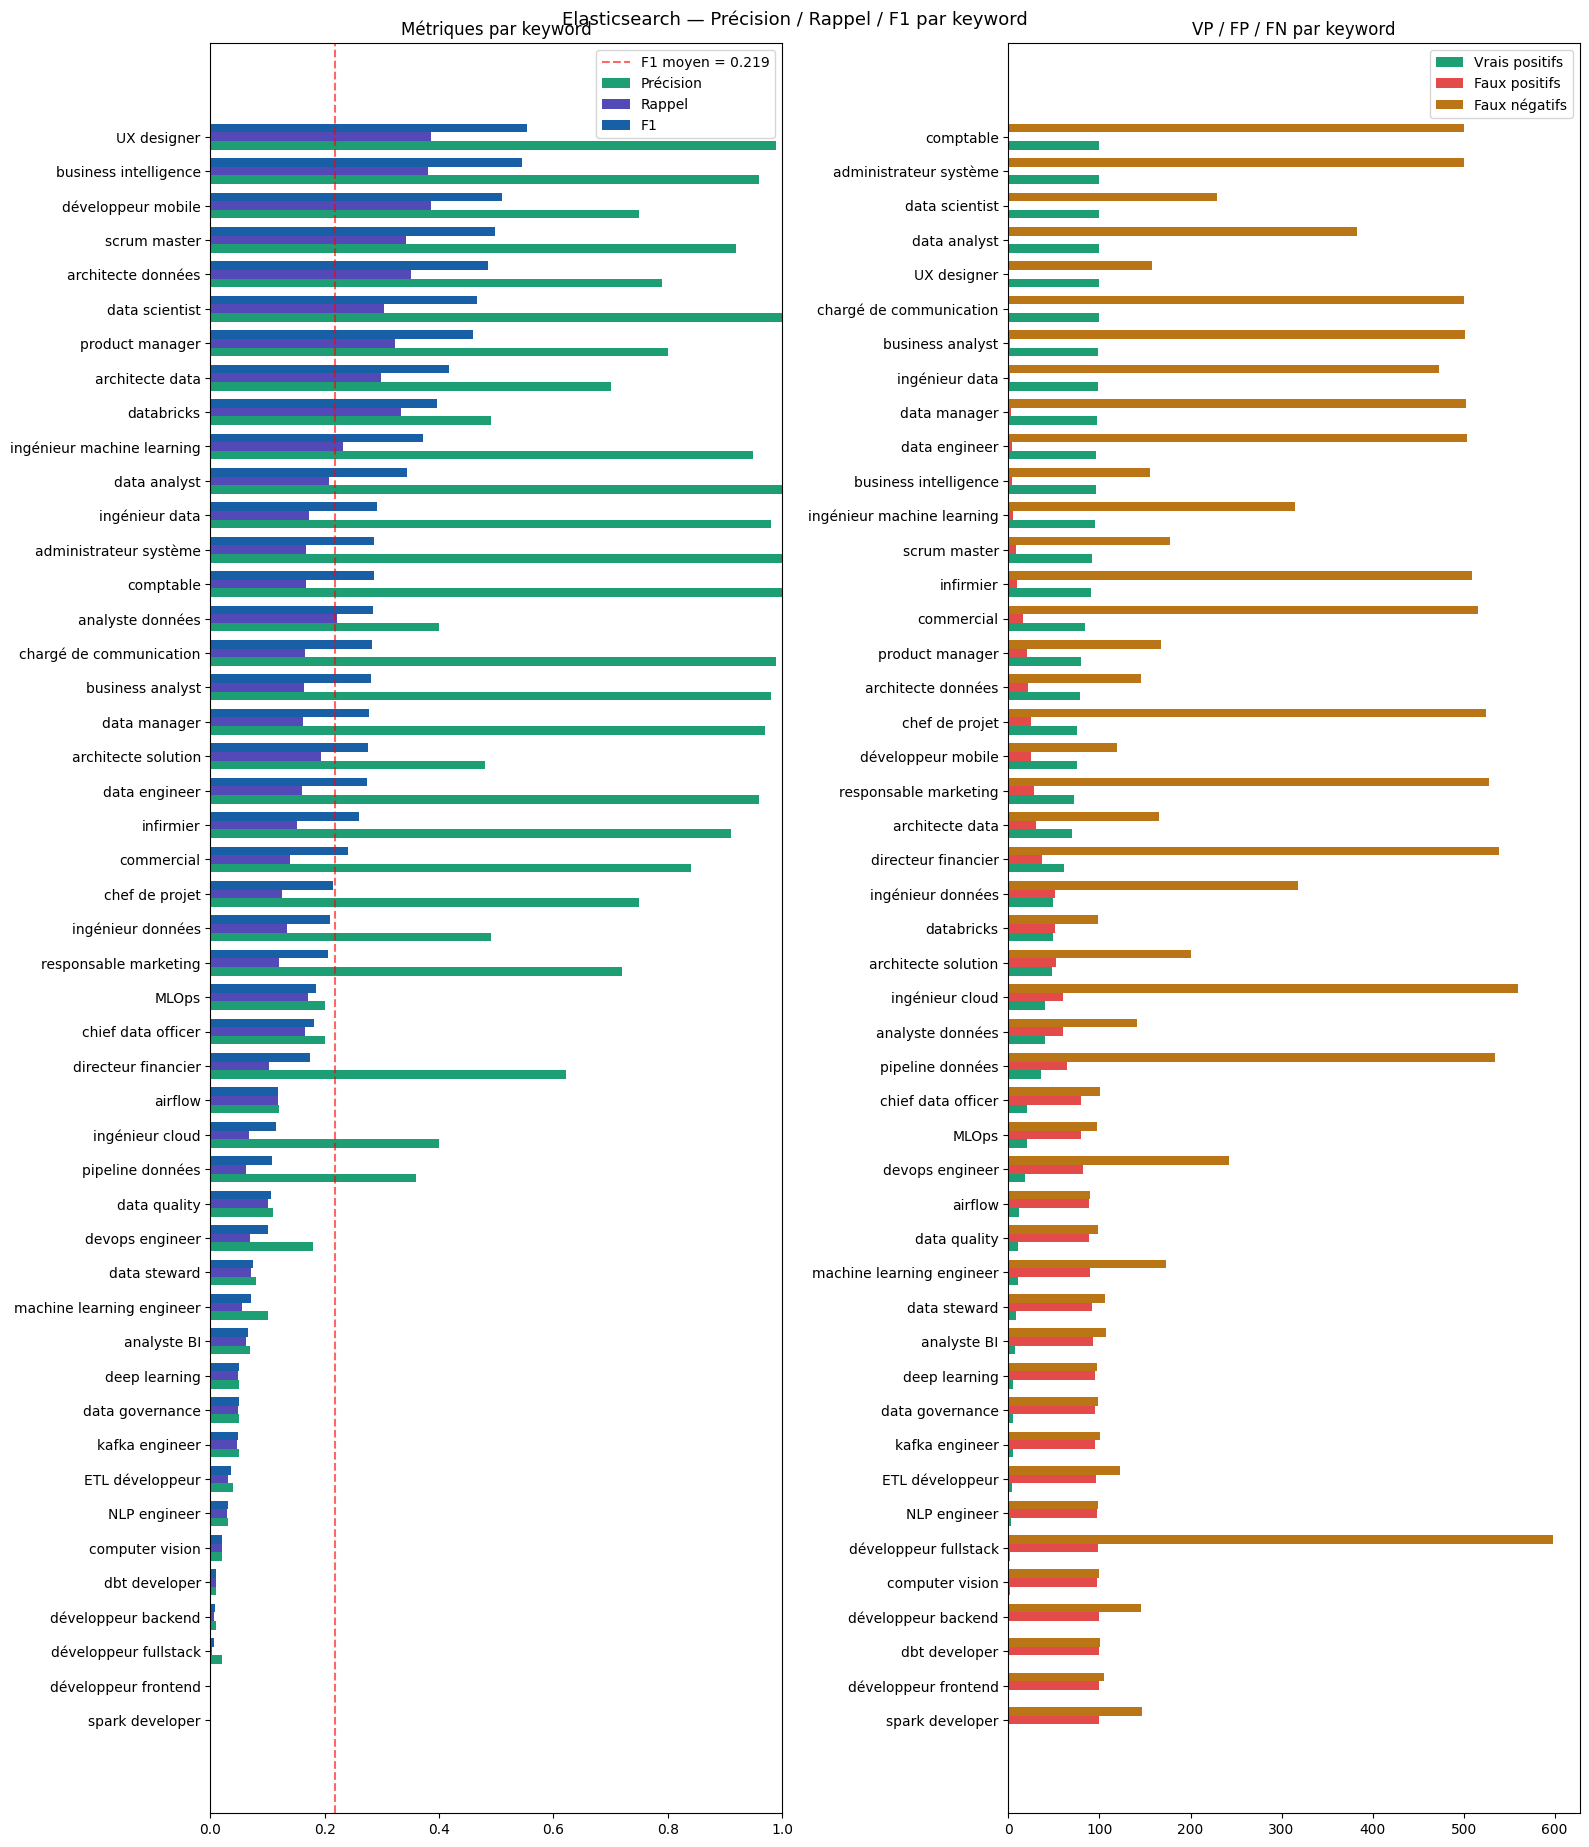

In [16]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Visualisations
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_resultats) * 0.4)))
fig.suptitle(
    "Elasticsearch — Précision / Rappel / F1 par keyword",
    fontsize=13
)

df_plot = df_resultats.sort_values("f1", ascending=True)

# ── Précision / Rappel / F1 par keyword ───────────────────────
x = np.arange(len(df_plot))
w = 0.25

axes[0].barh(x - w,   df_plot["precision"], w, label="Précision", color="#1D9E75")
axes[0].barh(x,       df_plot["rappel"],    w, label="Rappel",    color="#534AB7")
axes[0].barh(x + w,   df_plot["f1"],        w, label="F1",        color="#185FA5")
axes[0].set_yticks(x)
axes[0].set_yticklabels(df_plot["keyword"])
axes[0].set_xlim(0, 1)
axes[0].set_title("Métriques par keyword")
axes[0].axvline(
    x    = df_resultats["f1"].mean(),
    color = "red",
    linestyle = "--",
    alpha = 0.6,
    label = f"F1 moyen = {df_resultats['f1'].mean():.3f}"
)
axes[0].legend()

# ── VP / FP / FN par keyword ───────────────────────────────────
df_plot2 = df_resultats.sort_values("vrais_positifs", ascending=True)
x2 = np.arange(len(df_plot2))

axes[1].barh(x2 - w, df_plot2["vrais_positifs"], w,
             label="Vrais positifs",  color="#1D9E75")
axes[1].barh(x2,     df_plot2["faux_positifs"],  w,
             label="Faux positifs",   color="#E24B4A")
axes[1].barh(x2 + w, df_plot2["faux_negatifs"],  w,
             label="Faux négatifs",   color="#BA7517")
axes[1].set_yticks(x2)
axes[1].set_yticklabels(df_plot2["keyword"])
axes[1].set_title("VP / FP / FN par keyword")
axes[1].legend()

plt.tight_layout()
plt.savefig("eval_es_par_keyword.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7 — Comparaison avec les modèles ML
# ─────────────────────────────────────────────────────────────
"""
Maintenant que tu as les métriques ES par keyword,
tu peux comparer avec un modèle ML entraîné sur ml_keyword.

Le modèle ML répond à la même question :
"Cette offre appartient-elle au keyword X ?"
"""

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Charger le texte des offres
df_offres = pd.read_sql("""
    SELECT
        o.id,
        o.titre,
        o.description,
        STRING_AGG(DISTINCT c.competence, ' ') AS competences,
        ml.ml_keyword
    FROM offres o
    JOIN ml_labels ml ON ml.offre_id = o.id
    LEFT JOIN competences c ON c.offre_id = o.id
    GROUP BY o.id, o.titre, o.description, ml.ml_keyword
""", conn)

df_offres["texte"] = (
    df_offres["titre"].fillna("") + " " +
    df_offres["titre"].fillna("") + " " +
    df_offres["description"].fillna("") + " " +
    df_offres["competences"].fillna("")
)

# Évaluer chaque modèle keyword par keyword (one-vs-rest)
MODELES_ML = {
    "LR":  Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                  sublinear_tf=True)),
        ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                  sublinear_tf=True)),
        ("clf",   LinearSVC(max_iter=2000, class_weight="balanced")),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultats_ml = []

for keyword in keywords_uniques:
    print(f"keyword : {keyword}")
    # Variable cible binaire pour ce keyword
    y_kw = (df_offres["ml_keyword"] == keyword).astype(int).values
    X_kw = df_offres["texte"].values

    # Vérifier qu'on a les deux classes
    if y_kw.sum() < 5 or (1 - y_kw).sum() < 5:
        continue

    for nom_modele, pipeline in MODELES_ML.items():
        print(f"nom_modele : {nom_modele}")
        f = cross_val_score(pipeline, X_kw, y_kw, cv=cv,
                            scoring="f1", n_jobs=-1)
        p = cross_val_score(pipeline, X_kw, y_kw, cv=cv,
                            scoring="precision", n_jobs=-1)
        r = cross_val_score(pipeline, X_kw, y_kw, cv=cv,
                            scoring="recall", n_jobs=-1)

        resultats_ml.append({
            "keyword":   keyword,
            "modele":    nom_modele,
            "precision": round(p.mean(), 4),
            "rappel":    round(r.mean(), 4),
            "f1":        round(f.mean(), 4),
        })

df_ml = pd.DataFrame(resultats_ml)
print("Évaluation ML terminée")
print(df_ml.groupby("modele")[["precision", "rappel", "f1"]].mean().round(4))

keyword : data engineer
nom_modele : LR
nom_modele : SVM
keyword : ingénieur données
nom_modele : LR
nom_modele : SVM
keyword : ingénieur data
nom_modele : LR
nom_modele : SVM
keyword : pipeline données
nom_modele : LR
nom_modele : SVM
keyword : ETL développeur
nom_modele : LR
nom_modele : SVM
keyword : architecte données
nom_modele : LR
nom_modele : SVM
keyword : architecte data
nom_modele : LR
nom_modele : SVM
keyword : MLOps
nom_modele : LR
nom_modele : SVM
keyword : data scientist
nom_modele : LR
nom_modele : SVM
keyword : machine learning engineer
nom_modele : LR
nom_modele : SVM
keyword : ingénieur machine learning
nom_modele : LR
nom_modele : SVM
keyword : NLP engineer
nom_modele : LR
nom_modele : SVM
keyword : computer vision
nom_modele : LR
nom_modele : SVM
keyword : data analyst
nom_modele : LR
nom_modele : SVM
keyword : deep learning
nom_modele : LR
nom_modele : SVM
keyword : analyste données
nom_modele : LR
nom_modele : SVM
keyword : business analyst
nom_modele : LR
nom_mod

In [18]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8 — Tableau final ES vs ML par keyword
# ─────────────────────────────────────────────────────────────

# Fusionner ES et ML
df_es_kw = df_resultats[["keyword", "precision", "rappel", "f1"]]\
    .rename(columns={"precision": "P_ES", "rappel": "R_ES", "f1": "F1_ES"})

for nom_modele in MODELES_ML:
    df_modele = df_ml[df_ml["modele"] == nom_modele][
        ["keyword", "precision", "rappel", "f1"]
    ].rename(columns={
        "precision": f"P_{nom_modele}",
        "rappel":    f"R_{nom_modele}",
        "f1":        f"F1_{nom_modele}",
    })
    df_es_kw = df_es_kw.merge(df_modele, on="keyword", how="left")

print("\n=== COMPARAISON ES vs ML — Par keyword ===\n")
print(df_es_kw.to_string(index=False))

# Qui gagne ?
for nom_modele in MODELES_ML:
    col_f1 = f"F1_{nom_modele}"
    if col_f1 in df_es_kw.columns:
        df_es_kw[f"{nom_modele}_gagne"] = (
            df_es_kw[col_f1] > df_es_kw["F1_ES"]
        )
        nb_gagne = df_es_kw[f"{nom_modele}_gagne"].sum()
        total    = df_es_kw[f"{nom_modele}_gagne"].notna().sum()
        print(f"\n{nom_modele} gagne sur {nb_gagne}/{total} keywords")

conn.close()
print("\nConnexions fermées.")


=== COMPARAISON ES vs ML — Par keyword ===

                   keyword   P_ES   R_ES  F1_ES   P_LR   R_LR  F1_LR  P_SVM  R_SVM  F1_SVM
             data engineer 0.9600 0.1600 0.2743 0.2753 0.6767 0.3911 0.2687 0.5467  0.3600
         ingénieur données 0.4900 0.1335 0.2099 0.0840 0.5780 0.1466 0.0500 0.4907  0.0907
            ingénieur data 0.9800 0.1716 0.2921 0.2768 0.6533 0.3887 0.2689 0.5797  0.3672
          pipeline données 0.3600 0.0630 0.1073 0.2768 0.6533 0.3887 0.2689 0.5797  0.3672
           ETL développeur 0.0400 0.0315 0.0352 0.0056 0.1665 0.0108 0.0056 0.1665  0.0108
        architecte données 0.7900 0.3511 0.4862 0.0235 0.4133 0.0444 0.0088 0.1511  0.0167
           architecte data 0.7000 0.2979 0.4179 0.0240 0.4170 0.0454 0.0138 0.2340  0.0261
                     MLOps 0.2000 0.1709 0.1843 0.0027 0.0859 0.0051 0.0013 0.0428  0.0026
            data scientist 1.0000 0.3040 0.4662 0.0567 0.6351 0.1040 0.0432 0.5317  0.0799
 machine learning engineer 0.1000 0.0546 0.07